## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Global values

In [2]:
data_dir = "data"

### Load tokens

In [3]:
token_file = os.path.join(data_dir, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Collapse elided with unelided lemmas

In [4]:
tokens.loc[tokens["lemma"]=="δʼ", "lemma"] = "δέ"
tokens.loc[tokens["lemma"]=="τʼ", "lemma"] = "τε"
tokens.loc[tokens["lemma"]=="ἀλλʼ", "lemma"] = "ἀλλά"
tokens.loc[tokens["lemma"]=="ἄρʼ", "lemma"] = "ἄρα"
tokens.loc[tokens["lemma"]=="ἐπʼ", "lemma"] = "ἐπί"
tokens.loc[tokens["lemma"]=="οὐδʼ", "lemma"] = "οὐδέ"

### Select most frequent lemmas

In [5]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens.loc[~(tokens["pos"]=="PUNCT"), "lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas][:25])

lemma
δέ       21335
καί      13599
ὁ         9589
τε        5291
ἐγώ       3783
ἐν        3532
ὡς        3444
εἰμί      3346
σύ        3110
μέν       3082
ὅς        3059
οὐ        3050
ἀλλά      2636
γάρ       2607
ἄρα       2588
ἐπί       2531
εἰς       2372
αὐτός     2055
τις       2046
ἕ         1841
πᾶς       1796
οὐδέ      1767
ἀνήρ      1753
ἔχω       1715
ἄλλος     1666
Name: count, dtype: int64

## General methods

#### Sampling

For each "view" on the data, we're going to create a two-tiered set of slices. The first tier is a set of categorical groups that we suspect might represent significant structural differences among the tokens, such as author, speech versus narrative, etc. The second tier represents a hypothetically arbitrary divisino of each group into samples.

#### Hypotheses

Here's what we're looking for:

 - What is the distribution of sample sizes?
 - What are the lemma frequencies per 1000 words for each sample?
 - When we plot samples by lemma frequency, do we see separation between the groups?

## Experiment class

In [6]:
class Experiment(object):
    '''A bundle of input and output data related to one trial'''

    def __init__(self, tokens, feature_set, group_ids, sample_ids, name="", run=True, quiet=True):
        # meta
        self.name = name
        self.quiet = quiet
        
        # inputs
        self.tokens = tokens           # reference to the tokens data frame
        self.feature_set = feature_set # list of features to count; should be column names in tokens 
        self.group_ids = group_ids     # series of group labels, indexed to tokens
        self.sample_ids = sample_ids   # series of sample labels, indexed to tokens

        # outputs
        self.tokens_per_sample = None  # token counts per sample for normalization, series
        self.samples = None            # feature frequencies, data frame
        self.scaled = None             # scaled feature freqs
        self.pca_model = None          # principal component model
        self.pca = None                # PCA coordinates, data frame

        # auto run
        if run:
            self.run()

    
    def run(self):
        '''run all steps'''
        self.calc_sample_sizes()
        self.calc_feature_vectors()
        self.calc_pca()
        self.plot_pca()

    
    def calc_sample_sizes(self):
        '''tally tokens per sample'''

        self.tokens_per_sample = self.tokens.groupby(self.sample_ids).size()

        if not self.quiet:
            return sns.displot(self.tokens_per_sample)

    
    def calc_feature_vectors(self):
        '''generate feature vectors'''

        # tally feature counts
        self.samples = (pd.get_dummies(self.tokens["lemma"])[self.feature_set]
            .groupby(self.sample_ids)
            .agg("sum")
        )

        # normalize as freq / 1000 words
        self.samples = self.samples.div(self.tokens_per_sample, axis=0) * 1000

        if not self.quiet:
            return self.samples


    def calc_pca(self):
        '''calculate z-scores and pca'''

        # scaling
        self.scaled = pd.DataFrame(
            data = StandardScaler().fit_transform(self.samples),
            columns = self.samples.columns,
            index = self.samples.index,
        )

        # pca
        self.pca_model = PCA(n_components=3)
        self.pca = pd.DataFrame(
            data = self.pca_model.fit_transform(self.scaled), 
            columns = ["PC1", "PC2", "PC3"],
            index = self.samples.index,
        )

        if not self.quiet:
            loadings = pd.Series(self.pca_model.components_[0], index=self.samples.columns)
            return loadings.abs().sort_values(ascending=False).head(15)


    def plot_pca(self):
        '''generate a plot from pca coords'''
        labels = (self.group_ids
            .groupby(self.sample_ids)
            .agg("first")
            .values
        )

        # define figure, axes
        self.fig, ax = plt.subplots()

        # generate plot
        fg = sns.scatterplot(data=self.pca,
            x = "PC1",
            y = "PC2",
            hue = labels,
            ax = ax,
        )
        ax.set_title(self.name)

        if not self.quiet:
            return self.fig

## Authorship

Group IDs are works; sample IDs are books.

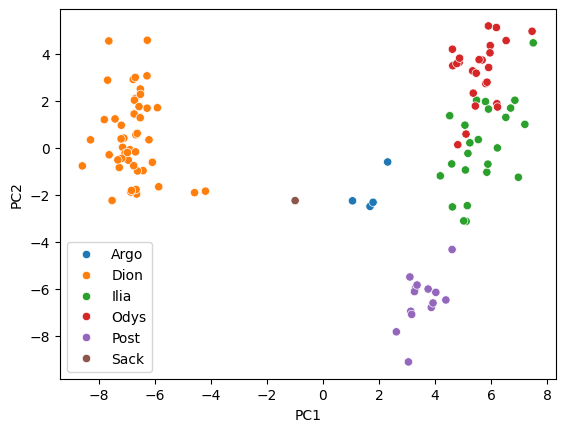

In [7]:
sample_ids = (tokens["work"] + " " + tokens["pref"].fillna("")).str.strip()
group_ids = sample_ids.str.slice(0, 4)

ex = Experiment(
    tokens = tokens, 
    feature_set = top_lemmas, 
    sample_ids = sample_ids, 
    group_ids = group_ids,
)

## Speech vs. Narrative

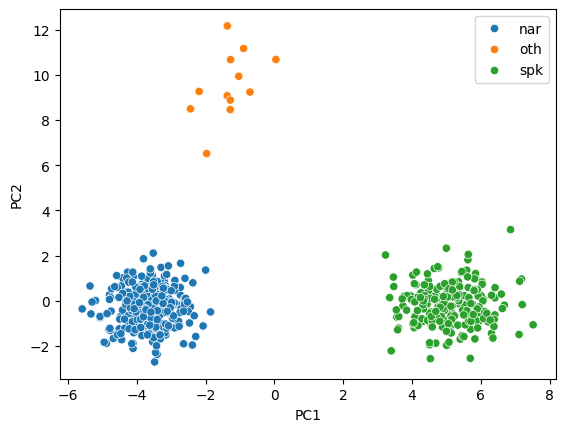

In [8]:
# identify tokens spoken by characters/narrator
#  (omit Odysseus as Apologue narrator)
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
group_ids = pd.Series("oth", index=tokens.index)
group_ids[nr_mask] = "nar"
group_ids[sp_mask] = "spk"

# create samples
sample_size = 1000
sample_ids = pd.Series(index=tokens.index)
for group in group_ids.unique():
    n_toks = sum(group_ids==group)
    sample_ids.loc[group_ids==group] = np.random.permutation(n_toks) // sample_size
sample_ids = group_ids + "-" + sample_ids.map(str)

# run experiment
ex = Experiment(
    tokens = tokens, 
    feature_set = top_lemmas, 
    sample_ids = sample_ids, 
    group_ids = group_ids,
)

## Compare different sample sizes

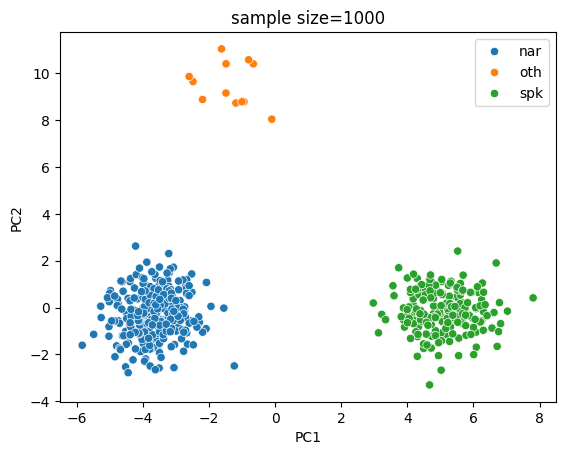

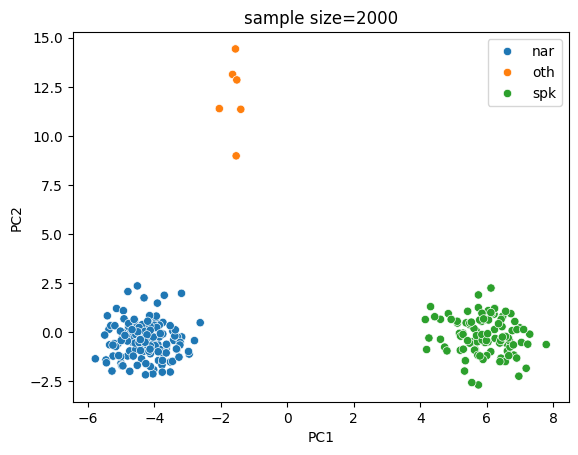

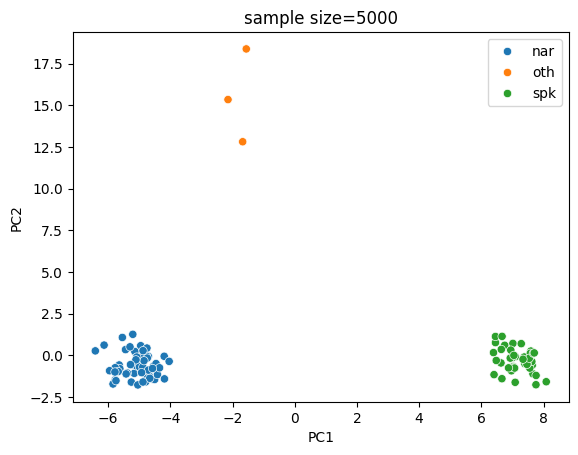

In [9]:
# identify tokens spoken by characters/narrator
#  (omit Odysseus as Apologue narrator)
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
group_ids = pd.Series("oth", index=tokens.index)
group_ids[nr_mask] = "nar"
group_ids[sp_mask] = "spk"

for sample_size in [1000, 2000, 5000]:
    # create samples
    sample_ids = pd.Series(index=tokens.index)
    for group in group_ids.unique():
        n_toks = sum(group_ids==group)
        sample_ids.loc[group_ids==group] = np.random.permutation(n_toks) // sample_size
    sample_ids = group_ids + "-" + sample_ids.map(str)
    
    # run experiment
    ex = Experiment(
        name = f"sample size={sample_size}",
        tokens = tokens, 
        feature_set = top_lemmas, 
        sample_ids = sample_ids, 
        group_ids = group_ids,
    )

## Author and narrative level combined

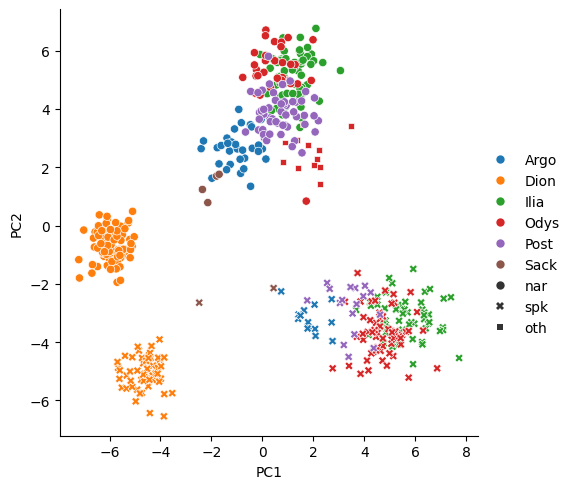

In [10]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
nara_group_ids = pd.Series("oth", index=tokens.index)
nara_group_ids[nr_mask] = "nar"
nara_group_ids[sp_mask] = "spk"

# Authorship groups
auth_group_ids = tokens["work"].str.slice(0,4)

# Combined group
group_ids = auth_group_ids + "-" + nara_group_ids

# create samples
sample_size = 1000
sample_ids = pd.Series(index=tokens.index)
for group in group_ids.unique():
    n_toks = sum(group_ids==group)
    sample_ids.loc[group_ids==group] = np.random.permutation(n_toks) // sample_size
sample_ids = group_ids + "-" + sample_ids.map(str)

# run experiment
ex_rand = Experiment(
    tokens = tokens, 
    feature_set = top_lemmas, 
    sample_ids = sample_ids, 
    group_ids = group_ids,
    run = False
)
ex_rand.calc_sample_sizes()
ex_rand.calc_feature_vectors()
ex_rand.calc_pca()

# plot
auth_labels = auth_group_ids.groupby(sample_ids).agg("first").values
nara_labels = nara_group_ids.groupby(sample_ids).agg("first").values

sns.relplot(data=ex_rand.pca,
    x = "PC1",
    y = "PC2",
    hue = auth_labels,
    style = nara_labels,
)

## Consecutive lines

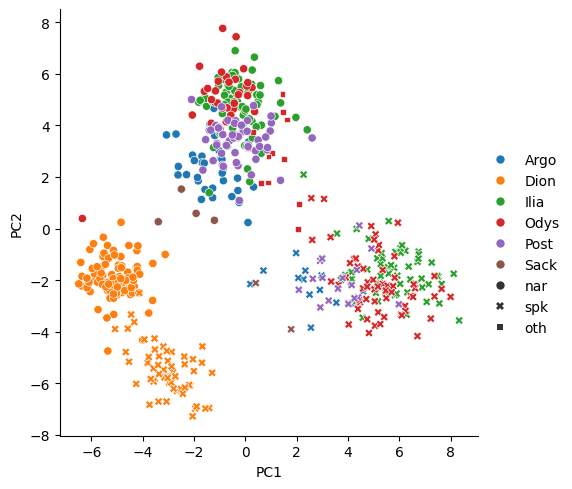

In [11]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
nara_group_ids = pd.Series("oth", index=tokens.index)
nara_group_ids[nr_mask] = "nar"
nara_group_ids[sp_mask] = "spk"

# Authorship groups
auth_group_ids = tokens["work"].str.slice(0,4)

# Combined group
group_ids = auth_group_ids + "-" + nara_group_ids

# create samples
sample_size = 1000
sample_ids = pd.Series(index=tokens.index)
for group in group_ids.unique():
    n_toks = sum(group_ids==group)
    sample_ids.loc[group_ids==group] = np.arange(n_toks) // sample_size
sample_ids = group_ids + "-" + sample_ids.map(str)

# run experiment
ex_cons = Experiment(
    tokens = tokens, 
    feature_set = top_lemmas, 
    sample_ids = sample_ids, 
    group_ids = group_ids,
    run = False
)
ex_cons.calc_sample_sizes()
ex_cons.calc_feature_vectors()
ex_cons.calc_pca()

# plot
auth_labels = auth_group_ids.groupby(sample_ids).agg("first").values
nara_labels = nara_group_ids.groupby(sample_ids).agg("first").values

sns.relplot(data=ex_cons.pca,
    x = "PC1",
    y = "PC2",
    hue = auth_labels,
    style = nara_labels,
)

## A first linear model

(-7.952689763967401, 8.473386985920518)

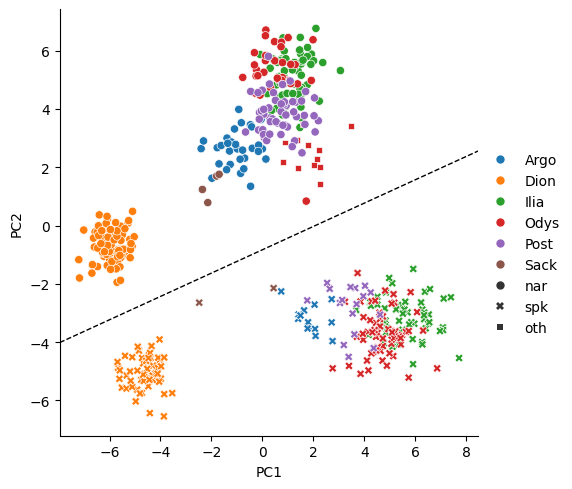

In [12]:
# fit on nar/spk only
mask = nara_labels != "oth"
X = ex_rand.pca.loc[mask, ["PC1", "PC2"]].values
y = (nara_labels[mask] == "spk").astype(int)

clf = LogisticRegression()
clf.fit(X, y)

# the decision boundary normal vector is clf.coef_
# project all points onto that axis
all_X = ex_rand.pca[["PC1", "PC2"]].values
proj = all_X @ clf.coef_.T + clf.intercept_
ex_rand.speech_score = pd.Series(proj.flatten(), index=ex_rand.pca.index)

# draw the figure again
g = sns.relplot(
    data = ex_rand.pca,
    x = "PC1", 
    y = "PC2",
    hue = auth_labels,
    style = nara_labels,
)
ax = g.ax

# get the axis limits from the plot
xlim = ax.get_xlim()

# solve for y at each x endpoint: coef[0]*x + coef[1]*y + intercept = 0
#   => y = -(coef[0]*x + intercept) / coef[1]
w = clf.coef_[0]
b = clf.intercept_[0]
xs = np.array(xlim)
ys = -(w[0] * xs + b) / w[1]

ax.plot(xs, ys, "k--", linewidth=1)
ax.set_xlim(xlim)  # restore limits so the line doesn't expand the plot